# MNIST Digit Classification
The notebook trains two classifiers on the MNIST handwritten-digit dataset:
1. Softmax regression: a single linear layer followed by softmax.
2. Two-layer neural network: a hidden layer of 128 sigmoid neurons, then a softmax output layer.

I implemented both models from scratch in NumPy to strengthen my understanding of neural networks.

In [1]:
# autoreload reflects changes here immediately —> no kernel restart needed.
%load_ext autoreload
%autoreload 2

### Folder Structure
```
neural-network/
├── data/
│   ├── data_processing.py           # load_data, train_val_split, generate_batched_data
│   └── MNIST/
│       ├── train-images-idx3-ubyte.gz   # 60,000 training images
│       ├── train-labels-idx1-ubyte.gz   # 60,000 training labels
│       ├── t10k-images-idx3-ubyte.gz    # 10,000 test images
│       └── t10k-labels-idx1-ubyte.gz    # 10,000 test labels
├── models/
│   ├── _base_network.py             # _BaseNetwork: softmax, loss, accuracy, activations
│   ├── softmax_regression.py        # SoftmaxRegression
│   └── two_layer_nn.py              # TwoLayerNeuralNetwork
├── optimizer/
│   ├── _base_optimizer.py           # _BaseOptimizer: L2 regularization
│   └── sgd.py                       # SGD
├── trainer.py                       # Trainer: training loop, evaluation, curves
├── main.ipynb                       # experiments: NumPy vs. PyTorch
└── requirements.txt
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from data.data_processing import load_data, train_val_split
from models.softmax_regression import SoftmaxRegression
from models.two_layer_nn import TwoLayerNeuralNetwork
from optimizer.sgd import SGD
from trainer import Trainer

### Load the MNIST Dataset

MNIST contains 70,000 grayscale images of handwritten digits (0–9): 60,000 for training and 10,000 for testing. Each image is 28×28 pixels.

In [3]:
# Each image is 28×28 = 784 pixels, normalized to [0, 1].
training_data, training_label, test_data, test_label = load_data(normalize=True)

print(f"Train Images: {training_data.shape}, Train Labels: {training_label.shape}")
print(f"Test Images: {test_data.shape}, Test Labels: {test_label.shape}")
print(f"Pixel dtype: {training_data.dtype}, range: [{training_data.min():.1f}, {training_data.max():.1f}]")
print(f"Label values: {np.unique(training_label)}")

Train Images: (60000, 28, 28), Train Labels: (60000,)
Test Images: (10000, 28, 28), Test Labels: (10000,)
Pixel dtype: float32, range: [0.0, 1.0]
Label values: [0 1 2 3 4 5 6 7 8 9]


### Visualization
Always look at the data before training. The result shows the first eight training images with their labels, providing a quick check that the images and labels were read correctly and remained paired.

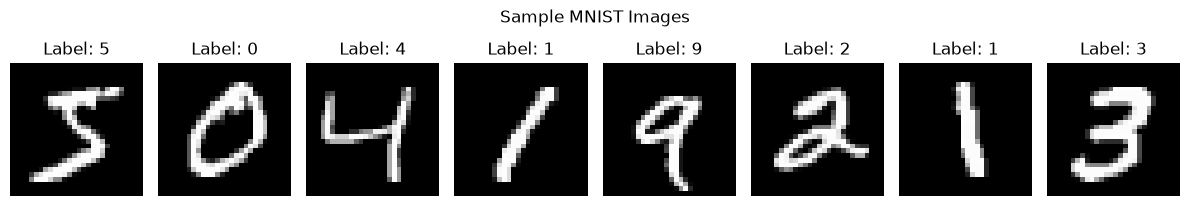

In [4]:
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, ax in enumerate(axes):
  ax.imshow(training_data[i].reshape(28, 28), cmap='gray')  # works whether or not the images are flattened
  ax.set_title(f'Label: {training_label[i]}')
  ax.axis('off')
plt.suptitle('Sample MNIST Images', y=1.02)
plt.tight_layout()
plt.show()

### Train and Validation Split

We split the 60,000 training images 80/20 into a **training set** (48,000 images) and a **validation set** (12,000 images). The test set remains untouched until the final evaluation, providing an honest estimate of performance on unseen data.

In [5]:
train_data, train_label, val_data, val_label = train_val_split(training_data, training_label)

print(f'train_data samples : {len(train_data)}  (expected: 48000)')
print(f'val_data samples   : {len(val_data)}  (expected: 12000)')

train_data samples : 48000  (expected: 48000)
val_data samples   : 12000  (expected: 12000)


### Softmax Regression Model

<p align="center"><img src="./img/softmax.png" alt="Softmax Regression model" width="520"></p>

- **Architecture**: Input → FC → Softmax

- **Model**: Each image $x$ (784 pixels) is mapped to 10 class scores by a single linear layer, and softmax turns the scores into probabilities:
  $$z = xW + b, \qquad p_k = \frac{e^{z_k}}{\sum_{j=1}^{C} e^{z_j}}$$
  with $W$ of shape (784, 10), $b$ of shape (10,), and $C = 10$ classes. The implementation subtracts each row's maximum score before exponentiating to prevent overflow without changing the result.

- **Loss**: Cross-entropy, the negative log-probability assigned to the correct class $y_n$, averaged over a batch of $N$ examples:
  $$\mathcal{L} = -\frac{1}{N}\sum_{n=1}^{N} \log p_{n,\,y_n}$$

- **Backward pass**: For a batch, stack the inputs into $X$ of shape $(N, 784)$ and the scores and probabilities into $Z$ and $P$ of shape $(N, 10)$. The gradient of the softmax combined with cross-entropy simplifies to the predicted probabilities minus the one-hot labels, divided by $N$ because the loss is averaged:
  $$\frac{\partial \mathcal{L}}{\partial Z} = \frac{P - \text{one-hot}(y)}{N}$$
  from which
  $$\frac{\partial \mathcal{L}}{\partial W} = X^\top \frac{\partial \mathcal{L}}{\partial Z}, \qquad \frac{\partial \mathcal{L}}{\partial b} = \sum_{n=1}^{N} \left(\frac{\partial \mathcal{L}}{\partial Z}\right)_{n}$$

- **Training**: Mini-batch SGD with a learning rate of 0.01, L2 regularization of $10^{-5}$ on the weights (not the bias), a batch size of 64, for 10 epochs. Each epoch, the `Trainer` reshuffles the data, runs forward → backward → update for every batch, then evaluates on the validation set. The plot shows training and validation loss per epoch.

> Here is an explanation of [deriving categorical cross-entropy and softmax](https://shivammehta25.github.io/posts/deriving-categorical-cross-entropy-and-softmax/).

Epoch [ 1/10]  Train loss : 1.0675, Accuracy: 0.7961  |  Validation loss : 0.6481, Accuracy 0.8648
Epoch [ 2/10]  Train loss : 0.6008, Accuracy: 0.8619  |  Validation loss : 0.5038, Accuracy 0.8805
Epoch [ 3/10]  Train loss : 0.5077, Accuracy: 0.8743  |  Validation loss : 0.4471, Accuracy 0.8877
Epoch [ 4/10]  Train loss : 0.4626, Accuracy: 0.8812  |  Validation loss : 0.4152, Accuracy 0.8952
Epoch [ 5/10]  Train loss : 0.4346, Accuracy: 0.8855  |  Validation loss : 0.3945, Accuracy 0.8976
Epoch [ 6/10]  Train loss : 0.4153, Accuracy: 0.8893  |  Validation loss : 0.3799, Accuracy 0.9005
Epoch [ 7/10]  Train loss : 0.4007, Accuracy: 0.8925  |  Validation loss : 0.3687, Accuracy 0.9020
Epoch [ 8/10]  Train loss : 0.3894, Accuracy: 0.8948  |  Validation loss : 0.3599, Accuracy 0.9042
Epoch [ 9/10]  Train loss : 0.3801, Accuracy: 0.8968  |  Validation loss : 0.3524, Accuracy 0.9053
Epoch [10/10]  Train loss : 0.3723, Accuracy: 0.8982  |  Validation loss : 0.3465, Accuracy 0.9064


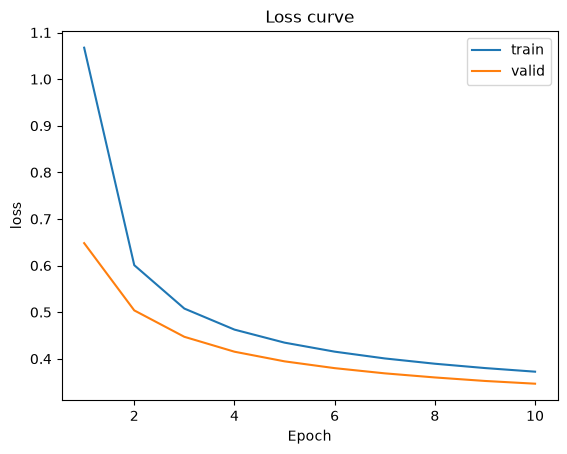

In [6]:
# Softmax regression
softmax = SoftmaxRegression()
trainer_softmax = Trainer(softmax, SGD(learning_rate=0.01, reg=1e-5), batch_size=64, epochs=10)
trainer_softmax.fit(train_data, train_label, val_data, val_label)
trainer_softmax.plot_curve("loss")

In [7]:
test_loss, test_acc = trainer_softmax.evaluate(test_data, test_label)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

Test loss: 0.3469, Test accuracy: 0.9076


### Two-Layer Neural Network Model

<p align="center"><img src="./img/twolayer.png" alt="Two-Layer Neural Network model" width="800"></p>

- **Architecture**: Input → FC₁ → Sigmoid → FC₂ → Softmax

- **Model**: A hidden layer of 128 units sits between the input and the output, which lets the network learn nonlinear features that a single linear layer cannot:
  $$h = \sigma(xW_1 + b_1), \qquad z = hW_2 + b_2, \qquad p_k = \frac{e^{z_k}}{\sum_{j=1}^{C} e^{z_j}}$$
  with $W_1$ of shape (784, 128), $b_1$ of shape (128,), $W_2$ of shape (128, 10), $b_2$ of shape (10,), and $C = 10$ classes. The hidden activation is the sigmoid, $\sigma(t) = \frac{1}{1 + e^{-t}}$, applied element-wise.

- **Initialization**: Weights are drawn from a normal distribution with standard deviation $\sqrt{1/\text{fan-in}}$ (simpler Xavier initialization), where fan-in is the number of inputs to the layer: 784 for $W_1$ and 128 for $W_2$. This keeps activation scales roughly constant from layer to layer. Biases start at zero.

- **Loss**: Cross-entropy, the negative log-probability assigned to the correct class $y_n$, averaged over a batch of $N$ examples:
  $$\mathcal{L} = -\frac{1}{N}\sum_{n=1}^{N} \log p_{n,\,y_n}$$

- **Backward pass**: For a batch, stack the inputs into $X$ of shape $(N, 784)$, the hidden pre-activations and activations into $Z_1$ and $H$ of shape $(N, 128)$, and the scores and probabilities into $Z_2$ and $P$ of shape $(N, 10)$. The gradient starts at the output, exactly as in softmax regression:
  $$\frac{\partial \mathcal{L}}{\partial Z_2} = \frac{P - \text{one-hot}(y)}{N}$$
  which gives the second layer's gradients:
  $$\frac{\partial \mathcal{L}}{\partial W_2} = H^\top \frac{\partial \mathcal{L}}{\partial Z_2}, \qquad \frac{\partial \mathcal{L}}{\partial b_2} = \sum_{n=1}^{N} \left(\frac{\partial \mathcal{L}}{\partial Z_2}\right)_{n}$$
  The chain rule then sends the gradient back through $W_2$ and the sigmoid, using $\sigma'(t) = \sigma(t)\,(1 - \sigma(t))$:
  $$\frac{\partial \mathcal{L}}{\partial H} = \frac{\partial \mathcal{L}}{\partial Z_2} W_2^\top, \qquad \frac{\partial \mathcal{L}}{\partial Z_1} = \frac{\partial \mathcal{L}}{\partial H} \odot \sigma(Z_1) \odot \big(1 - \sigma(Z_1)\big)$$
  where $\odot$ is element-wise multiplication. This gives the first layer's gradients:
  $$\frac{\partial \mathcal{L}}{\partial W_1} = X^\top \frac{\partial \mathcal{L}}{\partial Z_1}, \qquad \frac{\partial \mathcal{L}}{\partial b_1} = \sum_{n=1}^{N} \left(\frac{\partial \mathcal{L}}{\partial Z_1}\right)_{n}$$

- **Training**: Same setup as softmax regression, mini-batch SGD with L2 regularization of $10^{-5}$ on the weights, a batch size of 64, and 10 epochs, but with a learning rate of 0.1.


Epoch [ 1/10]  Train loss : 0.8741, Accuracy: 0.7860  |  Validation loss : 0.4205, Accuracy 0.8902
Epoch [ 2/10]  Train loss : 0.3920, Accuracy: 0.8923  |  Validation loss : 0.3316, Accuracy 0.9087
Epoch [ 3/10]  Train loss : 0.3335, Accuracy: 0.9045  |  Validation loss : 0.3014, Accuracy 0.9131
Epoch [ 4/10]  Train loss : 0.3049, Accuracy: 0.9121  |  Validation loss : 0.2777, Accuracy 0.9217
Epoch [ 5/10]  Train loss : 0.2848, Accuracy: 0.9179  |  Validation loss : 0.2633, Accuracy 0.9248
Epoch [ 6/10]  Train loss : 0.2687, Accuracy: 0.9222  |  Validation loss : 0.2518, Accuracy 0.9270
Epoch [ 7/10]  Train loss : 0.2538, Accuracy: 0.9274  |  Validation loss : 0.2390, Accuracy 0.9317
Epoch [ 8/10]  Train loss : 0.2404, Accuracy: 0.9311  |  Validation loss : 0.2280, Accuracy 0.9356
Epoch [ 9/10]  Train loss : 0.2282, Accuracy: 0.9335  |  Validation loss : 0.2185, Accuracy 0.9380
Epoch [10/10]  Train loss : 0.2167, Accuracy: 0.9380  |  Validation loss : 0.2106, Accuracy 0.9418


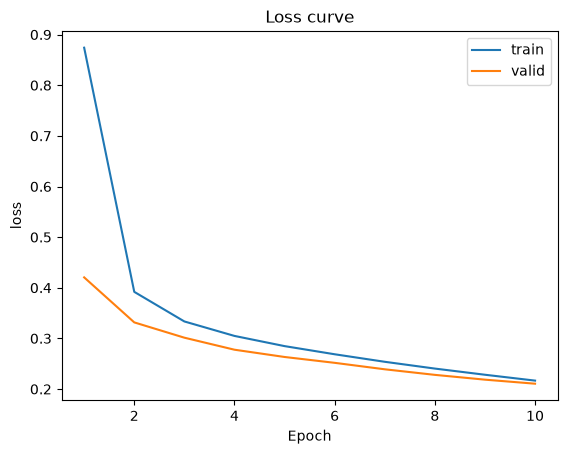

In [8]:
# Two-layer network
mlp = TwoLayerNeuralNetwork(hidden_size=128)
trainer_mlp = Trainer(mlp, SGD(learning_rate=0.1, reg=1e-5), batch_size=64, epochs=10)
trainer_mlp.fit(train_data, train_label, val_data, val_label)
trainer_mlp.plot_curve("loss")

In [9]:
test_loss, test_acc = trainer_mlp.evaluate(test_data, test_label)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}")

Test loss: 0.2095, Test accuracy: 0.9397


## Pytorch

Modern models are rarely implemented from scratch. PyTorch is an open-source deep learning and machine learning framework known for its ease of use with tensors that run on GPUs and for automatic differentiation that computes every gradient. The user designs only the forward pass, and PyTorch handles backpropagation, optimization, and scaling, which is why it has become the standard tool for research and many industries.

| NumPy implementation | PyTorch equivalent |
|---|---|
| `forward` in each model | `nn.Module.forward` built from `nn.Sequential` layers |
| `backward` in each model | `loss.backward()` (automatic differentiation) |
| `softmax` + `cross_entropy_loss` | `nn.CrossEntropyLoss` |
| `SGD` + `apply_L2_regularization` | `optim.SGD` with `weight_decay` |
| `generate_batched_data` | `DataLoader(shuffle=True)` |


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

### Data Preparation
The NumPy arrays from above are converted to PyTorch tensors

> `DataLoader` wraps the training tensors and yields shuffled mini-batches of 64, reshuffling every epoch, the same role `generate_batched_data` plays in the NumPy version.

In [11]:
# numpy -> tensor
# training and validation data
tensor_train_data = torch.from_numpy(train_data)
tensor_val_data = torch.from_numpy(val_data)

# CrossEntropyLoss rejects uint8 labels
tensor_train_label = torch.from_numpy(train_label.astype("int64"))  
tensor_val_label = torch.from_numpy(val_label.astype("int64"))

# test data
tensor_test_data = torch.from_numpy(test_data)
tensor_test_label = torch.from_numpy(test_label.astype("int64"))

# mini-batches, reshuffled every epoch
train_loader = DataLoader(TensorDataset(tensor_train_data, tensor_train_label), batch_size=64, shuffle=True)

### Training and Evaluation Functions

`train_model` trains any model and prints its progress each epoch:

- **Optimizer**: SGD with the parameters split into two groups, so L2 regularization (`weight_decay`) applies to the weights only, exactly like `apply_L2_regularization` in the NumPy optimizer. Biases are identified as the 1-dimensional parameters.
- **Each batch**: Forward pass → loss → `optimizer.zero_grad()` → `loss.backward()` → `optimizer.step()`. `zero_grad` is required because PyTorch *adds* new gradients to existing ones rather than replacing them.
- **Each epoch**: Training loss and accuracy are averaged over all batches, weighted by batch size; then the model is evaluated on the full validation set.
- **Validation**: `model.eval()` switches layers such as dropout and batch normalization to inference behavior (these models have none, but it's good practice), and `torch.no_grad()` stops PyTorch from tracking operations for backpropagation, saving memory and time.

Accuracies here are printed as percentages, while the NumPy `Trainer` prints fractions.

In [12]:
def train_model(model, lr=0.1, reg=1e-5, epochs=10, seed=12):
    torch.manual_seed(seed)
    
    criterion = nn.CrossEntropyLoss()

    # L2 regularization on weights only, like apply_L2_regularization
    weights = [p for p in model.parameters() if p.ndim > 1]
    biases = [p for p in model.parameters() if p.ndim == 1]
    optimizer = optim.SGD([
        {"params": weights, "weight_decay": reg},
        {"params": biases, "weight_decay": 0.0},
    ], lr=lr)

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss = 0
        total_correct = 0
        
        for X, y in train_loader:
            outputs = model(X)
            loss = criterion(outputs, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item() * len(y)
            pred = outputs.argmax(dim=1)
            correct = (pred == y).sum().item()
            total_correct += correct
            
        train_loss = total_loss / len(tensor_train_label)
        train_acc = total_correct / len(tensor_train_label) * 100
        
        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(tensor_val_data)

            val_loss = criterion(val_outputs, tensor_val_label).item()
            predictions = val_outputs.argmax(dim=1)
            val_correct = (predictions == tensor_val_label).sum().item()
            val_acc = (val_correct / len(tensor_val_label)) * 100

        print(f"Epoch [{epoch + 1:>2}/{epochs:>2}]  "
              f"Train loss : {train_loss:.4f}, Accuracy: {train_acc:.2f}%  |  "
              f"Validation loss : {val_loss:.4f}, Accuracy {val_acc:.2f}%")

    return model

### Model Evaluation 

`evaluate_model` runs a single forward pass without updating the model and returns the loss, the accuracy, and the predicted class for each example. The predictions can be used for further analysis, such as per-class accuracy or a confusion matrix.

In [13]:
def evaluate_model(model, X, y):
    criterion = nn.CrossEntropyLoss()
    model.eval()
    with torch.no_grad():
        outputs = model(X)
        loss = criterion(outputs, y).item()
        predictions = outputs.argmax(dim=1)
        correct = (predictions == y).sum().item()
        acc = (correct / len(y)) * 100
    
    return loss, acc, predictions

### Softmax Regression (PyTorch)

`nn.Flatten` reshapes each `(28, 28)` image into 784 values, and `nn.Linear(784, 10)` contains the weight matrix and bias. The model outputs raw scores (logits) without a softmax layer because `nn.CrossEntropyLoss` applies softmax internally in a numerically stable way; adding one here would apply it twice.

Hyperparameters match the NumPy version.

In [14]:
class SoftmaxRegressionModel(nn.Module):
    def __init__(self, input_size=28*28, num_classes=10):
        super().__init__()
        self.sequential = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, num_classes),
        )

        # match numpy: W ~ N(0, 0.01^2), b = 0
        linear = self.sequential[1]
        nn.init.normal_(linear.weight, mean=0.0, std=0.01)
        nn.init.zeros_(linear.bias)
        
    def forward(self, X):
        return self.sequential(X)
    
model = SoftmaxRegressionModel(input_size=28*28, num_classes=10)
softmax_model = train_model(model, lr=0.01)

Epoch [ 1/10]  Train loss : 1.0733, Accuracy: 79.44%  |  Validation loss : 0.6492, Accuracy 86.28%
Epoch [ 2/10]  Train loss : 0.6006, Accuracy: 86.16%  |  Validation loss : 0.5035, Accuracy 88.17%
Epoch [ 3/10]  Train loss : 0.5073, Accuracy: 87.40%  |  Validation loss : 0.4475, Accuracy 88.92%
Epoch [ 4/10]  Train loss : 0.4621, Accuracy: 88.11%  |  Validation loss : 0.4154, Accuracy 89.40%
Epoch [ 5/10]  Train loss : 0.4342, Accuracy: 88.60%  |  Validation loss : 0.3944, Accuracy 89.88%
Epoch [ 6/10]  Train loss : 0.4149, Accuracy: 88.94%  |  Validation loss : 0.3799, Accuracy 90.07%
Epoch [ 7/10]  Train loss : 0.4004, Accuracy: 89.25%  |  Validation loss : 0.3683, Accuracy 90.38%
Epoch [ 8/10]  Train loss : 0.3890, Accuracy: 89.46%  |  Validation loss : 0.3595, Accuracy 90.50%
Epoch [ 9/10]  Train loss : 0.3798, Accuracy: 89.66%  |  Validation loss : 0.3525, Accuracy 90.60%
Epoch [10/10]  Train loss : 0.3719, Accuracy: 89.83%  |  Validation loss : 0.3464, Accuracy 90.70%


In [15]:
test_loss, test_acc, preds = evaluate_model(softmax_model, tensor_test_data, tensor_test_label)
print(f"Test loss: {test_loss:.4f}, Accuracy: {test_acc:.2f}%")

Test loss: 0.3466, Accuracy: 90.61%


### Two-Layer Neural Network (PyTorch)

The same architecture and hyperparameters as the NumPy network. 

In [16]:
class TwoLayerNeuralNetworkModel(nn.Module):
    def __init__(self, input_size=28*28, num_classes=10, hidden_size=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_size),
            nn.Sigmoid(),
            nn.Linear(hidden_size, num_classes),
        )

        # match Simpler Xavier
        for layer in (self.net[1], self.net[3]):
            nn.init.normal_(layer.weight, mean=0.0, std=(1.0 / layer.in_features) ** 0.5)
            nn.init.zeros_(layer.bias)
        
    def forward(self, X):
        return self.net(X)
    
model = TwoLayerNeuralNetworkModel(input_size=28*28, num_classes=10, hidden_size=128)
mlp_model = train_model(model, lr=0.1)

Epoch [ 1/10]  Train loss : 0.8686, Accuracy: 79.24%  |  Validation loss : 0.4161, Accuracy 89.23%
Epoch [ 2/10]  Train loss : 0.3900, Accuracy: 89.28%  |  Validation loss : 0.3288, Accuracy 90.77%
Epoch [ 3/10]  Train loss : 0.3327, Accuracy: 90.49%  |  Validation loss : 0.2965, Accuracy 91.52%
Epoch [ 4/10]  Train loss : 0.3039, Accuracy: 91.27%  |  Validation loss : 0.2803, Accuracy 92.03%
Epoch [ 5/10]  Train loss : 0.2837, Accuracy: 91.85%  |  Validation loss : 0.2620, Accuracy 92.43%
Epoch [ 6/10]  Train loss : 0.2677, Accuracy: 92.26%  |  Validation loss : 0.2495, Accuracy 92.75%
Epoch [ 7/10]  Train loss : 0.2531, Accuracy: 92.66%  |  Validation loss : 0.2370, Accuracy 93.23%
Epoch [ 8/10]  Train loss : 0.2397, Accuracy: 93.10%  |  Validation loss : 0.2287, Accuracy 93.41%
Epoch [ 9/10]  Train loss : 0.2283, Accuracy: 93.47%  |  Validation loss : 0.2186, Accuracy 93.95%
Epoch [10/10]  Train loss : 0.2170, Accuracy: 93.79%  |  Validation loss : 0.2092, Accuracy 94.23%


In [17]:
test_loss, test_acc, preds = evaluate_model(mlp_model, tensor_test_data, tensor_test_label)
print(f"Test loss: {test_loss:.4f}, Accuracy: {test_acc:.2f}%")

Test loss: 0.2098, Accuracy: 94.03%
